In [1]:
import tensorflow as tf
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.applications import MobileNetV2
import matplotlib.pyplot as plt

# --- 1. Define Constants ---
IMG_WIDTH, IMG_HEIGHT = 224, 224
IMG_SIZE = (IMG_WIDTH, IMG_HEIGHT)
BATCH_SIZE = 32
DATA_DIR = "/content/drive/MyDrive/lion tiger cat dog"  # Main folder
TRAIN_DIR = f"{DATA_DIR}/train"
TEST_DIR = f"{DATA_DIR}/test"
EPOCHS = 25 # Start with 15-20 epochs for this phase

# --- 2. Load Datasets ---
print("Loading datasets...")

# Use image_dataset_from_directory to load the data
# It automatically infers class names from folder names (cat, dog, lion, tiger)
# and handles resizing.
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'  # 'int' for sparse_categorical_crossentropy
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=False # No need to shuffle test data
)


# Get class names
class_names = train_dataset.class_names
print(f"Found classes: {class_names}")

# Configure dataset for performance
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

# --- 3. Preprocessing Layer ---
# MobileNetV2 expects pixel values in the range [-1, 1]
# We use its dedicated preprocessing function for this.
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

# --- 4. Build the Model (Phase 1: Feature Extraction) ---

# 1. Load the Base Model (MobileNetV2)
# We exclude the top (classification) layer and use 'imagenet' weights.
base_model = MobileNetV2(
    input_shape=(IMG_WIDTH, IMG_HEIGHT, 3),
    include_top=False,
    weights='imagenet'
)

# 2. Freeze the Base Model
# This is the most important step for feature extraction.
# We lock all the weights in the MobileNetV2 layers.
base_model.trainable = False
print(f"Base model trainable status: {base_model.trainable}")

# 3. Add Your New Classifier
# We define the input layer
inputs = Input(shape=(IMG_WIDTH, IMG_HEIGHT, 3))

# We apply the preprocessing *as a layer*
# This ensures it's done on the GPU and is part of the saved model.
x = preprocess_input(inputs)

# Pass the preprocessed input to the frozen base model
x = base_model(x, training=False) # 'training=False' is important

# Add the GlobalAveragePooling2D layer to flatten features
x = GlobalAveragePooling2D()(x)

# Add the final Dense layer for our 4 classes
# We use 'softmax' for multi-class classification.
outputs = Dense(len(class_names), activation='softmax')(x)

# Create the final model
model = Model(inputs, outputs)

# --- 5. Compile the Model ---
# We use 'adam' as the optimizer and 'sparse_categorical_crossentropy'
# because our labels are integers (0, 1, 2, 3), not one-hot encoded.
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Let's look at the model structure
model.summary()

# --- 6. Train the Model ---
print("\nStarting training (Phase 1)...")

history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=test_dataset
)

print("Training complete.")

# --- 7. (Optional) Evaluate and Plot Results ---
print("\nEvaluating model on test data...")
loss, accuracy = model.evaluate(test_dataset)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Plot training & validation accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

Loading datasets...
Found 720 files belonging to 4 classes.
Found 80 files belonging to 4 classes.

📊 Image count per class (Train):


AttributeError: '_PrefetchDataset' object has no attribute 'class_indices'

In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# --- 1. Get True Labels and Model Predictions ---

# We need to get all the true labels (y_true) and
# the model's predictions (y_pred) from the test dataset.

# Get the model's predictions (these will be probabilities)
# model.predict() will iterate through the entire test_dataset
y_pred_probs = model.predict(test_dataset)

# Convert the probabilities into a single predicted class (the one with the highest prob)
y_pred = np.argmax(y_pred_probs, axis=1)

# Get the true labels
# We must iterate through the dataset to extract the labels
# This ensures the order matches the predictions
y_true = []
for images, labels in test_dataset:
    y_true.extend(labels.numpy())

# Convert to a numpy array for scikit-learn
y_true = np.array(y_true)

# --- 2. Generate the Confusion Matrix ---

# Now we can compare the true labels vs. the predicted labels
cm = confusion_matrix(y_true, y_pred)

# --- 3. Plot the Confusion Matrix ---

# We'll use Seaborn for a nice-looking heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,  # Show the numbers in each cell
    fmt='d',     # Format as integers
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix', fontsize=15)
plt.show()

NameError: name 'model' is not defined

Loading datasets...
Found 720 files belonging to 4 classes.
Found 80 files belonging to 4 classes.
Found classes: ['cat', 'dog', 'lion', 'tiger']

Calculating image counts...
Train counts: {'cat': 180, 'dog': 180, 'lion': 180, 'tiger': 180}
Test counts: {'cat': 20, 'dog': 20, 'lion': 20, 'tiger': 20}


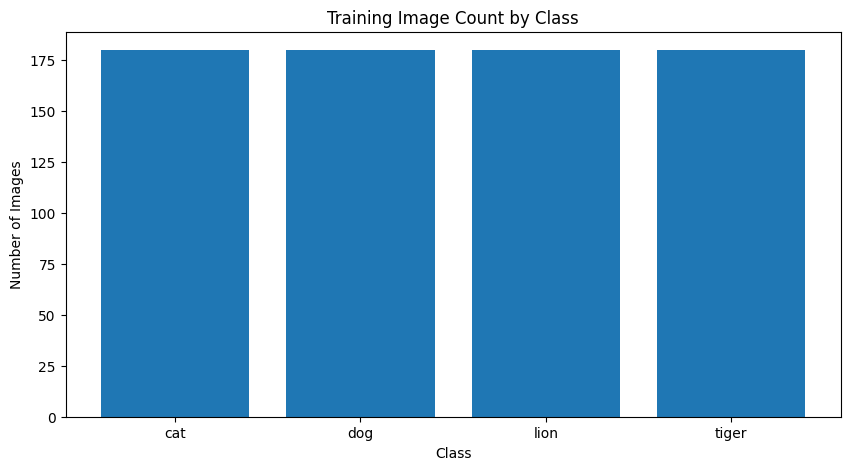

Displaying sample images from training set...


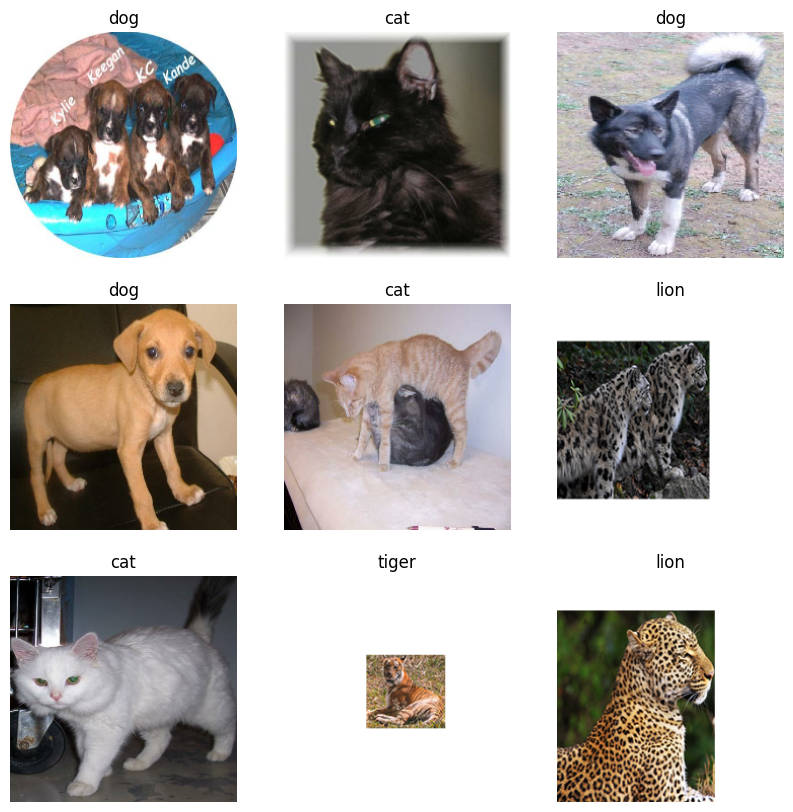


Datasets configured for performance.
Base model trainable status: False


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


Starting training (Phase 1)...
Epoch 1/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 51s 2s/step - accuracy: 0.5958 - loss: 1.0302 - val_accuracy: 0.9875 - val_loss: 0.1402
Epoch 2/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.9757 - loss: 0.1565 - val_accuracy: 0.9875 - val_loss: 0.0632
Epoch 3/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.9865 - loss: 0.0826 - val_accuracy: 1.0000 - val_loss: 0.0425
Epoch 4/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.9938 - loss: 0.0567 - val_accuracy: 1.0000 - val_loss: 0.0329
Epoch 5/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.9981 - loss: 0.0421 - val_accuracy: 1.0000 - val_loss: 0.0263
Epoch 6/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.9981 - loss: 0.0333 - val_accuracy: 1.0000 - val_loss: 0.0218
Epoch 7/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.9996 - loss: 0.0272 - val_accuracy: 1.0000 - val_loss: 0.0185
Epoch 8/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 1.0000 - loss: 0.0227 - 

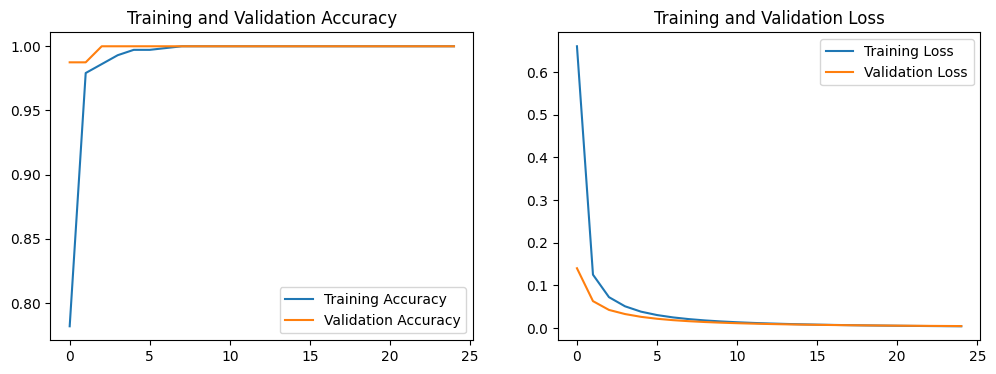


Generating confusion matrix...
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step


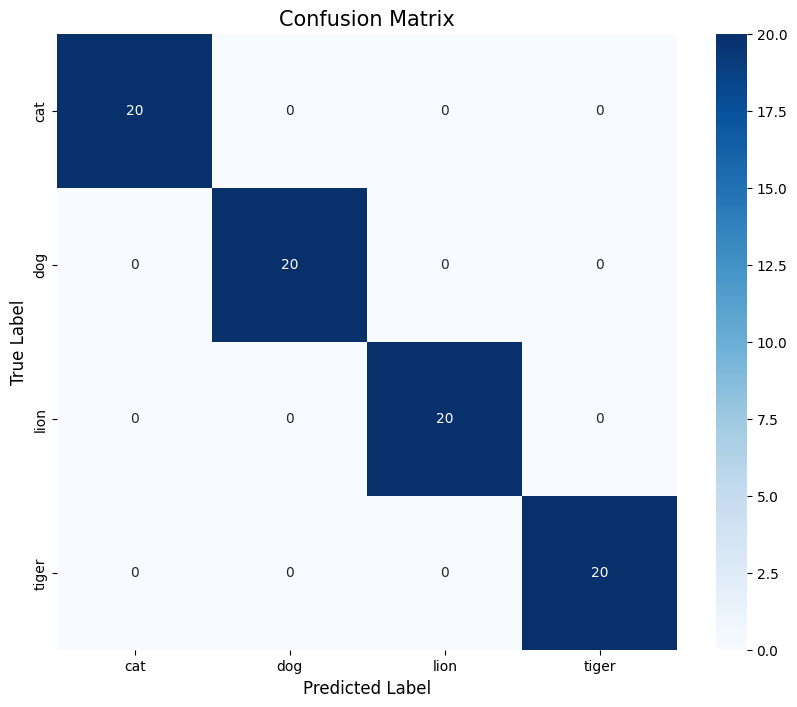

Script finished.


In [4]:
import tensorflow as tf
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.applications import MobileNetV2
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
import os  # <-- Added for counting files

# --- 1. Define Constants ---
IMG_WIDTH, IMG_HEIGHT = 224, 224
IMG_SIZE = (IMG_WIDTH, IMG_HEIGHT)
BATCH_SIZE = 32
DATA_DIR = "/content/drive/MyDrive/lion tiger cat dog"  # Main folder
TRAIN_DIR = f"{DATA_DIR}/train"
TEST_DIR = f"{DATA_DIR}/test"
EPOCHS = 25 # Start with 15-20 epochs for this phase

# --- 2. Load Datasets ---
print("Loading datasets...")

# Use image_dataset_from_directory to load the data
# It automatically infers class names from folder names (cat, dog, lion, tiger)
# and handles resizing.
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'  # 'int' for sparse_categorical_crossentropy
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=False # No need to shuffle test data
)

# Get class names
class_names = train_dataset.class_names
print(f"Found classes: {class_names}")

# --- 2.A: Visualize the Data (NEW SECTION) ---

# --- Visual Dataset image count by class ---
print("\nCalculating image counts...")
train_counts = {}
test_counts = {}

# Count files in each class directory
for class_name in class_names:
    train_class_dir = os.path.join(TRAIN_DIR, class_name)
    test_class_dir = os.path.join(TEST_DIR, class_name)

    # Count files in the training directory for this class
    train_counts[class_name] = len(os.listdir(train_class_dir))
    # Count files in the test directory for this class
    test_counts[class_name] = len(os.listdir(test_class_dir))

print(f"Train counts: {train_counts}")
print(f"Test counts: {test_counts}")

# Plot the training counts
plt.figure(figsize=(10, 5))
plt.bar(train_counts.keys(), train_counts.values())
plt.title("Training Image Count by Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

# --- Show some samples of each class ---
print("Displaying sample images from training set...")
plt.figure(figsize=(10, 10))
# Take one batch from the training dataset
for images, labels in train_dataset.take(1):
    for i in range(9):  # Display first 9 images in the batch
        ax = plt.subplot(3, 3, i + 1)
        # Images are float32 in [0, 255], cast to uint8 for imshow
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()


# --- 2.B: Configure Dataset for Performance ---
# (This was part of the original section 2)
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)
print("\nDatasets configured for performance.")

# --- 3. Preprocessing Layer ---
# MobileNetV2 expects pixel values in the range [-1, 1]
# We use its dedicated preprocessing function for this.
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

# --- 4. Build the Model (Phase 1: Feature Extraction) ---

# 1. Load the Base Model (MobileNetV2)
# We exclude the top (classification) layer and use 'imagenet' weights.
base_model = MobileNetV2(
    input_shape=(IMG_WIDTH, IMG_HEIGHT, 3),
    include_top=False,
    weights='imagenet'
)

# 2. Freeze the Base Model
# This is the most important step for feature extraction.
# We lock all the weights in the MobileNetV2 layers.
base_model.trainable = False
print(f"Base model trainable status: {base_model.trainable}")

# 3. Add Your New Classifier
# We define the input layer
inputs = Input(shape=(IMG_WIDTH, IMG_HEIGHT, 3))

# We apply the preprocessing *as a layer*
# This ensures it's done on the GPU and is part of the saved model.
x = preprocess_input(inputs)

# Pass the preprocessed input to the frozen base model
x = base_model(x, training=False) # 'training=False' is important

# Add the GlobalAveragePooling2D layer to flatten features
x = GlobalAveragePooling2D()(x)

# Add the final Dense layer for our 4 classes
# We use 'softmax' for multi-class classification.
outputs = Dense(len(class_names), activation='softmax')(x)

# Create the final model
model = Model(inputs, outputs)

# --- 5. Compile the Model ---
# We use 'adam' as the optimizer and 'sparse_categorical_crossentropy'
# because our labels are integers (0, 1, 2, 3), not one-hot encoded.
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Let's look at the model structure
model.summary()

# --- 6. Train the Model ---
print("\nStarting training (Phase 1)...")

history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=test_dataset
)

print("Training complete.")

# --- 7. (Optional) Evaluate and Plot Results ---
print("\nEvaluating model on test data...")
loss, accuracy = model.evaluate(test_dataset)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Plot training & validation accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

# --- 8. Confusion Matrix ---
# (This was the second script you provided, now integrated)

print("\nGenerating confusion matrix...")

# --- 1. Get True Labels and Model Predictions ---

# We need to get all the true labels (y_true) and
# the model's predictions (y_pred) from the test dataset.

# Get the model's predictions (these will be probabilities)
# model.predict() will iterate through the entire test_dataset
y_pred_probs = model.predict(test_dataset)

# Convert the probabilities into a single predicted class (the one with the highest prob)
y_pred = np.argmax(y_pred_probs, axis=1)

# Get the true labels
# We must iterate through the dataset to extract the labels
# This ensures the order matches the predictions
y_true = []
for images, labels in test_dataset:
    y_true.extend(labels.numpy())

# Convert to a numpy array for scikit-learn
y_true = np.array(y_true)

# --- 2. Generate the Confusion Matrix ---

# Now we can compare the true labels vs. the predicted labels
cm = confusion_matrix(y_true, y_pred)

# --- 3. Plot the Confusion Matrix ---

# We'll use Seaborn for a nice-looking heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,  # Show the numbers in each cell
    fmt='d',     # Format as integers
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix', fontsize=15)
plt.show()

print("Script finished.")